<a href="https://colab.research.google.com/github/DSiabatto/SQL_data_journey/blob/main/SQL_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SQL Notes**


* [MySQL CheatSheet CodeWithHarry](https://www.codewithharry.com/blogpost/mysql-cheatsheet)
* [SQL Hoja de Referencia Datademia](https://drive.google.com/file/d/1z_7QDFOA_9Fgiu1BsO186MM9KMSl2Dnh/view)

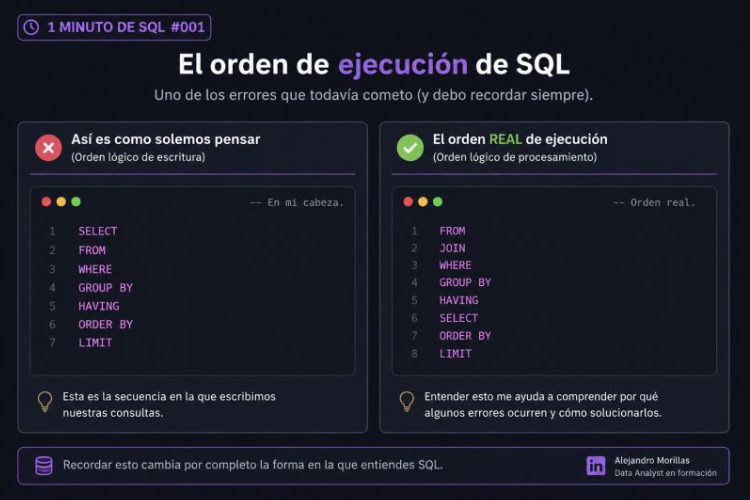

#**PROJECT DATE SORT**
Contains project date classification ("START","MIDDLE","END","START-END")

```
/*
xD
*/
WITH nodes as (
    select p1.task_id as id1,p2.task_id as id2,
    datediff(p1.end_date,p2.start_date) as dif,
    row_number() OVER (order by p1.end_date) as t
    from projects p1, projects p2
    HAVING dif =0 OR dif =1
    order by t
), phase as (
    SELECT t,id1,CASE
     WHEN id1 !=id2 AND dif=0 AND
     id1 in (SELECT id1 FROM nodes group by id1 having count(id1)=2) AND
     id1 in (SELECT id2 FROM nodes GROUP BY id2 having count(id2)=2)
     THEN "Mid"
     WHEN id1 !=id2 AND dif=0 and
     id1 in (SELECT id1 as co FROM nodes group by id1 having count(id1)=2)
     THEN "Start"
     WHEN id1 =id2 AND dif=1 AND
     id1 in (SELECT id1 FROM nodes group by id1 having count(id1)=1) AND
     id1 in (SELECT id2 FROM nodes group by id2 having count(id2)=2)
     THEN "END"
     WHEN id1 =id2 AND dif=1 AND
        id1 in (SELECT id1 FROM nodes group by id1 having count(id1)=1) AND
     id1 in (SELECT id2 FROM nodes group by id2 having count(id2)=1)
     THEN "START-END"
    ELSE "PH"
     END as cas
 FROM Nodes
 HAVING cas!="PH"
 ), Clas as (
    select task_id, cas,
    rank() over (PARTITION BY cas ORDER BY t) as r
    FROM phase ph
    JOIN projects p on p.task_id=ph.id1
     WHERE cas!="Mid"
     ORDER BY t
     )
 , inifin as (SELECT c1.task_id as ini , c2.task_id as fin
 FROM clas c1, clas c2
    WHERE c1.cas!="START-END" AND  c2.cas!="START-END" AND c1.cas!="END"
    AND c1.r=c2.r
    AND c1.task_id!=c2.task_id
    UNION
SELECT task_id,task_id from clas
WHERE cas="START-END"
 )
 select proj.start_date,proj1.end_date from inifin
JOIN projects proj on inifin.ini=proj.task_id
JOIN projects proj1 on inifin.fin=proj1.task_id
order by datediff(proj1.end_date,proj.start_date),proj.start_date

```




#**SELF JOIN**
```
SELECT A.CustomerName AS CustomerName1, B.CustomerName AS CustomerName2, A.City
FROM Customers A, Customers B
WHERE A.CustomerID <> B.CustomerID
AND A.City = B.City
ORDER BY A.City;
```



#**PRIME NUMBERS**


```
with recursive num as (
    select 2 as i
    UNION
    select i+1
    from num
    WHERE i<10
), t as
    (select n1.i from num AS n1
WHERE not exists (
    select 1 from num as n2
WHERE
    n2.i < n1.i and n1.i%n2.i=0))
select group_concat(i separator "&") from t;
```



Table

```
CREATE TABLE person (
  firstname VARCHAR(100),
  company_id INT
);

CREATE TABLE company (
id INT,
company_name VARCHAR(100)
);

INSERT INTO person (firstname, company_id) VALUES
('John', 1), ('Sarah', 2), ('Mark', 1), ('Tania', 3);

INSERT INTO company (id, company_name) VALUES
(1, 'something'), (2, 'another co'), (3, 'west'), (4, 'northern');

UPDATE company
SET company_name='south'
WHERE id=2;
```




#JOIN

*   (INNER) JOIN: matching values in both tables
*   LEFT (OUTER) JOIN: all rows from the left table, and only the matched rows from the right table
*   RIGHT (OUTER) JOIN: all rows from the right table, and only the matched rows from the left table
*   FULL (OUTER) JOIN: all rows when there is a match in either the left or right table
```
SELECT Orders.OrderID, Customers.CustomerName, Orders.OrderDate
FROM Orders
INNER JOIN Customers ON Orders.CustomerID=Customers.CustomerID;
```



# BASIC WINDOW FUNCTION
Nothing within parentheses

```
SELECT employee_id, salary,
       RANK() OVER (ORDER BY salary DESC) AS salary_rank
FROM employees;
```



#Partition & Pivot

Partition works with Window functions such as Row_Number(), SUM() or Rank()
**OVER**` clause specifies the window over which the function operates.


```
with pivot as( SELECT name, Occupation,
    Row_number() OVER (PARTITION by Occupation Order by name) as rn
FROM Occupations)
select min(CASE
    WHEN Occupation="Doctor"
    THEN name
    END),
    max(CASE
    WHEN Occupation="Professor"
    THEN name
    END),
    max(if(Occupation="Singer",name,null)),
    min(if(Occupation="Actor",name,null))
     from pivot
    
    Group by rn;
```



#Node Diagram

```
SELECT n,
    CASE
     WHEN p is NULL THEN "Root"
     WHEN n in (SELECT distinct (p) from BST) THEN "Inner"
     ELSE "Leaf"     
     END
From BST
order by n;
```



# Count Distinct ft JOIN
```
select
    co.company_code,
    co.founder,
    count(DISTINCT e.lead_manager_code),
    count(DISTINCT e.senior_manager_code),
    count(DISTINCT e.manager_code),
    count(DISTINCT e.employee_code)
From Company co
JOIN Employee e ON co.company_code = e.company_code
group by co.company_code, co.founder
order by co.company_code;


```

